# Homework 7: K-Means Clustering and Image Segmentation
**Name:** Aragya Goyal | **Student ID:** 4541458 | **D value:** 58

In [1]:
# Import packages
import numpy as np
import scipy
import matplotlib.pyplot as plt

# Define Globals
D = 58

## Question 1
### Part A: Supervised vs. Unsupervised  
**Text Response:**
1. The K-means algorithm is an unsupervised algorithm because it does not require the output y-labels. So the algorithm does not learn from the relationship between the input features to the output but rather through the patterns within the data itself. Instead of the y-labels, the algorithm uses the distance between the data points to guide the clustering into K groups.
2. Compaered to linear regression, in K-means, the algorithm controls the position of the cluster centroids which are updated in each step of the algorithm. These play the function of theta. And instead of h(x), the K-means algorithm uses the cluster assignment of each of the points which are then used to calculate the SSD. 

### Part B: Convergence and Initialization
**Text Response:**
1. TODO
2. TODO

### Part C: Choosing K
**Text Response:**
1. TODO

## Question 2: Implementing K-Means
### Part A: Single-Run K-Means

In [2]:
def kmeans_single(X, K, iters, random_seed=D):
    # Set Random Seed
    np.random.seed(random_seed)

    # Get size of X
    m, n = X.shape

    # Initialize K Centers
    indices = np.random.choice(m, K, replace=False)
    means = X[indices]

    # Initialize ssd history
    ssd_history = []

    # Loop through iterations
    for i in range(iters):
        # Compute distances and assign nearest
        dists = scipy.spatial.distance.cdist(X, means, 'euclidean')
        ids = np.argmin(dists, axis=1) + 1

        # Recompute centroids
        for k in range(K):
            mask = (ids == k + 1)
            if np.any(mask):
                means[k] = X[mask].mean(axis=0)

        # Compute ssd
        ssd = 0
        for k in range(K):
            mask = (ids == k + 1)
            if np.any(mask):
                ssd += np.sum((X[mask] - means[k]) ** 2)
        ssd_history.append(ssd)
    
    return ids, means, ssd_history

### Part B: Verification on Toy Data  
**Pre-Computation check:**  
TODO

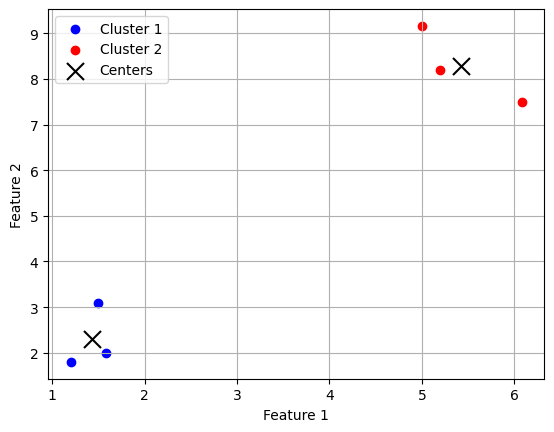

Final SSD: 3.077866666666667


In [11]:
# Define X_toy and other parameters
X_toy = np.array([
    [1.0 + D/100, 2.0],
    [1.5, 2.5 + D/100],
    [1.2, 1.8],
    [5.0, 8.0 + D/50],
    [5.5 + D/100, 7.5],
    [5.2, 8.2]
])
K = 2
iters = 10

# Run K-means
ids, means, ssd_history = kmeans_single(X_toy, K, iters, D)

# Figure output
plt.figure()
colors = ['blue', 'red']
for k in range(1, K+1):
    mask = (ids == k)
    plt.scatter(X_toy[mask, 0], X_toy[mask, 1], c=colors[k-1], label=f'Cluster {k}')
plt.scatter(means[:, 0], means[:, 1], c='black', marker='x', s=150, label='Centers')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

# Report final SSD
print(f"Final SSD: {ssd_history[-1]}")

**Text response:**  
K-means was able to successfully separate the two groups. The final SSD for my D value of 58 was 3.08. This matches my expectations as the value is relatively low since the data has two clear clusters with a large gap in between them. This means that it was easy for K-means clustering to find the correct groups.

### Part C: Multiple Restarts

In [8]:
# Define kmeans_multiple
def kmeans_multiple(X, K, iters, R, base_seed):
    best_ids = None
    best_means = None
    best_ssd = np.inf
    best_ssd_history = None

    # Run kmeans_single R times with incremented seed
    for r in range(R):
        ids, means, ssd_history = kmeans_single(X, K, iters, base_seed + r)
        final_ssd = ssd_history[-1]
        if final_ssd < best_ssd:
            best_ids = ids
            best_means = means
            best_ssd = final_ssd
            best_ssd_history = ssd_history

    return best_ids, best_means, best_ssd, best_ssd_history

# Run on toy data
K = 2
iters = 10
R = 5
ids, means, best_ssd, best_ssd_history = kmeans_multiple(X_toy, K, iters, R, D)
print(f"Best SSD: {best_ssd}")

Best SSD: 3.077866666666667


**Text Response:**  
TODO

### Part D: Convergence Analysis

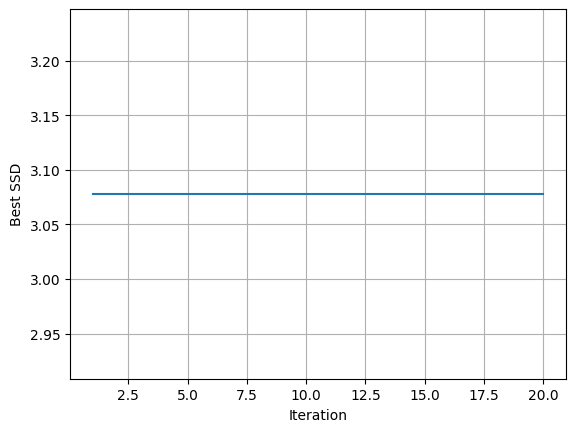

In [ ]:
# Run with toy data for 20 iterations
K = 2
iters = 20
R = 5
ids, means, best_ssd, best_ssd_history = kmeans_multiple(X_toy, K, iters, R, D)

# Plot the best ssd history
plt.figure()
plt.plot(range(1, 21), best_ssd_history)
plt.xlabel('Iteration')
plt.ylabel('Best SSD')
plt.title('Best SSD vs. Iterations')
plt.grid(True)
plt.show()